170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Treniņa datu forma: (50000, 32, 32, 3)
Testa datu forma: (10000, 32, 32, 3)
Pikseļu vērtību diapazons: 0 - 255
Klašu skaits: 10


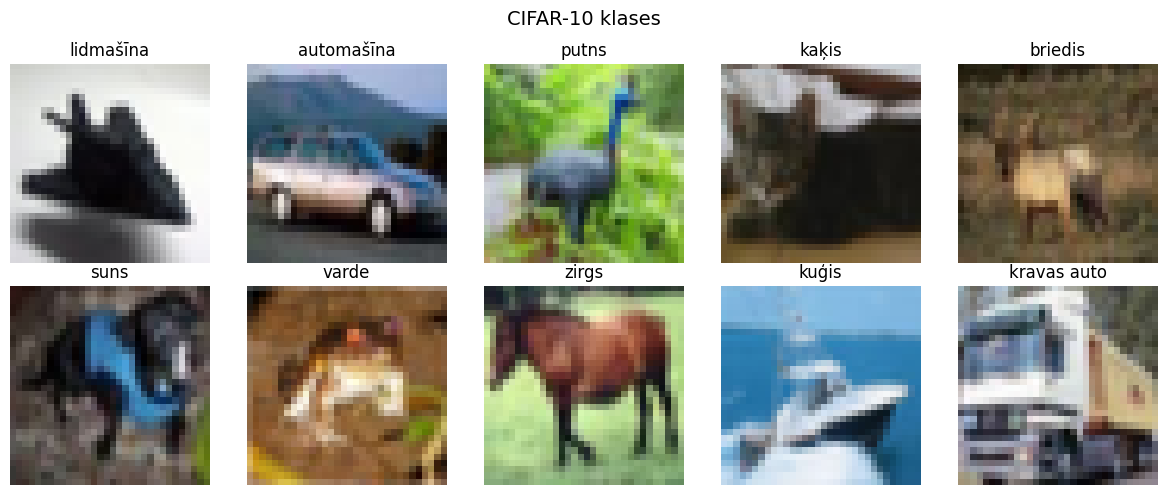

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# CIFAR-10 klašu nosaukumi
class_names = [
    "lidmašīna", "automašīna", "putns", "kaķis", "briedis",
    "suns", "varde", "zirgs", "kuģis", "kravas auto"
]

# Datu ielāde
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Datu struktūras analīze
print("Treniņa datu forma:", X_train.shape)
print("Testa datu forma:", X_test.shape)
print("Pikseļu vērtību diapazons:", X_train.min(), "-", X_train.max())
print("Klašu skaits:", len(class_names))

# Vizualizācija — pa vienam attēlam no katras klases
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    # Atrodam pirmo attēlu no katras klases
    idx = (y_train.flatten() == i).argmax()
    axes[i].imshow(X_train[idx])
    axes[i].set_title(class_names[i])
    axes[i].axis("off")

plt.suptitle("CIFAR-10 klases", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalizācija — dalām ar 255, lai iegūtu vērtības 0-1
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print("Pikseļu vērtību diapazons pēc normalizācijas:")
print("Min:", X_train_norm.min(), "Max:", X_train_norm.max())

# Data augmentation — treniņa laikā attēli tiks nejauši mainīti
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

# datagen pielāgošana
datagen.fit(X_train_norm)

Pikseļu vērtību diapazons pēc normalizācijas:
Min: 0.0 Max: 1.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Modeļa izveide
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),  # izslēdz 50% neironu, lai novērstu pārmācīšanos
    Dense(10, activation="softmax")  # 10 klases
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    datagen.flow(X_train_norm, y_train, batch_size=64),
    epochs=20,
    validation_data=(X_test_norm, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 128ms/step - accuracy: 0.3513 - loss: 1.7549 - val_accuracy: 0.4641 - val_loss: 1.4844
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.4815 - loss: 1.4473 - val_accuracy: 0.5326 - val_loss: 1.2788
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.5313 - loss: 1.3275 - val_accuracy: 0.5865 - val_loss: 1.1602
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.5638 - loss: 1.2441 - val_accuracy: 0.5913 - val_loss: 1.1309
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.5849 - loss: 1.1844 - val_accuracy: 0.6320 - val_loss: 1.0447
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.6046 - loss: 1.1355 - val_accuracy: 0.6504 - val_loss: 0.9961
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.6162 - loss: 1.0948 - val_accuracy: 0.6794 - val_loss: 0.9183
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 117ms/step - accuracy: 0.6353 - loss: 

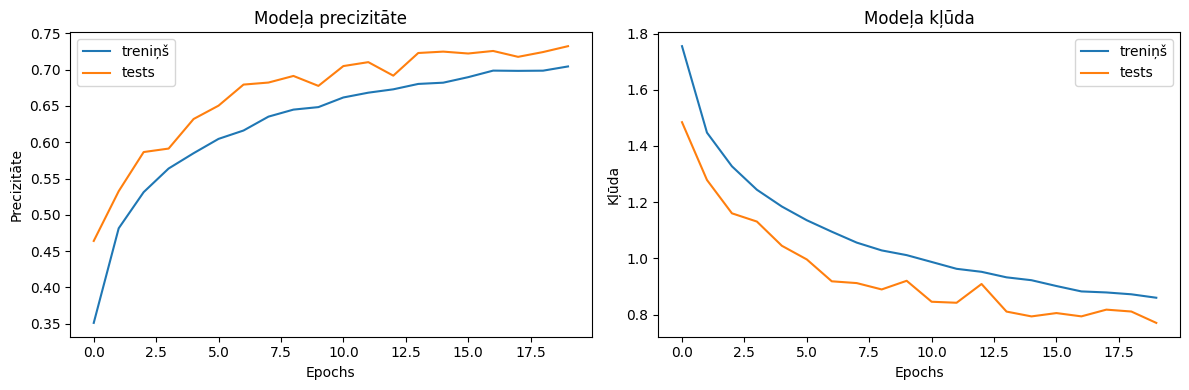

In [ ]:
# Rezultātu vizualizācija
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Precizitāte
ax1.plot(history.history["accuracy"], label="treniņš")
ax1.plot(history.history["val_accuracy"], label="tests")
ax1.set_title("Modeļa precizitāte")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Precizitāte")
ax1.legend()

# Kļūda
ax2.plot(history.history["loss"], label="treniņš")
ax2.plot(history.history["val_loss"], label="tests")
ax2.set_title("Modeļa kļūda")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Kļūda")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save
model.save("cifar10_cnn_model.keras")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model

# Palielinām attēlus no 32x32 uz 96x96
X_train_resized = tf.image.resize(X_train_norm, (96, 96))
X_test_resized = tf.image.resize(X_test_norm, (96, 96))

print("Jaunie izmēri:", X_train_resized.shape)

# Transfer learning modelis
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(96,96,3))
base_model.trainable = False  # neskolojam bāzes modeli, tikai mūsu slāņus

# Pievienojam savus slāņus
inputs = Input(shape=(96,96,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)

transfer_model = Model(inputs, outputs)

transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Jaunie izmēri: (50000, 96, 96, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_transfer = transfer_model.fit(
    X_train_resized,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_resized, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 425s 531ms/step - accuracy: 0.7505 - loss: 0.7079 - val_accuracy: 0.7734 - val_loss: 0.6481
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 391s 500ms/step - accuracy: 0.8073 - loss: 0.5467 - val_accuracy: 0.8038 - val_loss: 0.5636
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 460s 523ms/step - accuracy: 0.8277 - loss: 0.4883 - val_accuracy: 0.8040 - val_loss: 0.5578
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 434s 513ms/step - accuracy: 0.8454 - loss: 0.4414 - val_accuracy: 0.8129 - val_loss: 0.5426
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 416s 532ms/step - accuracy: 0.8558 - loss: 0.4083 - val_accuracy: 0.8086 - val_loss: 0.5798
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 398s 509ms/step - accuracy: 0.8689 - loss: 0.3698 - val_accuracy: 0.8020 - val_loss: 0.6020
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 410s 525ms/step - accuracy: 0.8825 - loss: 0.3333 - val_accuracy: 0.8183 - val_loss: 0.5709
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 411s 526ms/step - accuracy: 0.8925 -

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.6 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/street.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 422.3ms
Speed: 18.6ms preprocess, 422.3ms inference, 51.1ms postprocess per image at shape (1, 3, 640, 480)


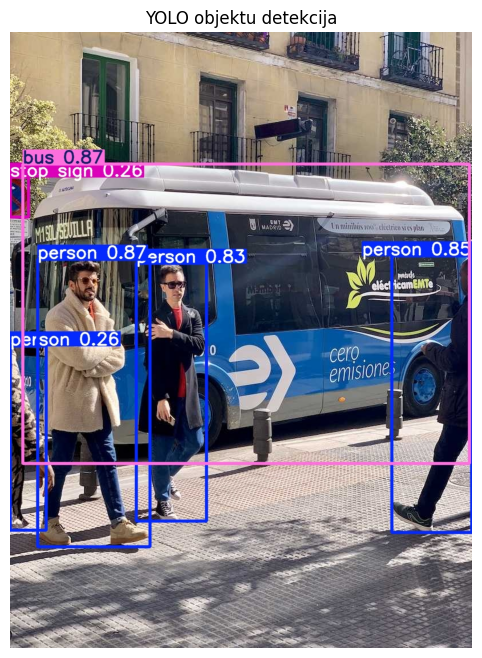

In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Lejupielādējam testa attēlu
!wget -q -O street.jpg "https://ultralytics.com/images/bus.jpg"

# Ielādējam YOLO modeli
model_yolo = YOLO("yolov8n.pt")

# Palaidām detekciju
results = model_yolo("street.jpg")

# Saglabājam rezultātu
results[0].save("street_result.jpg")

# Parādām rezultātu
img = mpimg.imread("street_result.jpg")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO objektu detekcija")
plt.show()

In [5]:
!apt-get install -y tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


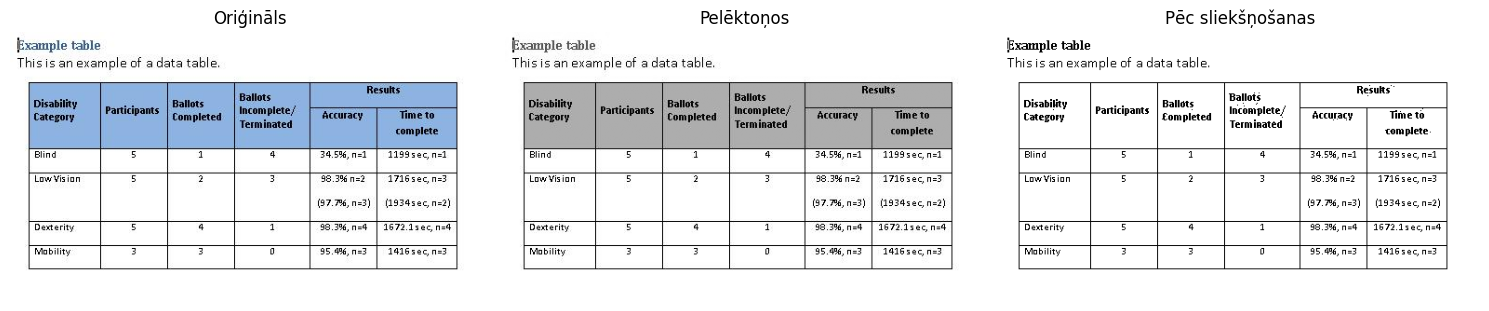

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Lejupielādējam testa attēlu ar tekstu
!wget -q -O document.png "https://www.w3.org/WAI/WCAG21/Techniques/pdf/img/table-word.jpg"

# Ielādējam attēlu
image = cv2.imread("document.png")

# Pārvēršam pelēktoņos
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Sliekšņošana — teksts kļūst melns, fons balts
thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)[1]

# Parādām oriģinālu un apstrādāto attēlu
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax1.set_title("Oriģināls")
ax1.axis("off")

ax2.imshow(gray, cmap="gray")
ax2.set_title("Pelēktoņos")
ax2.axis("off")

ax3.imshow(thresh, cmap="gray")
ax3.set_title("Pēc sliekšņošanas")
ax3.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import pytesseract
from PIL import Image

# OCR uz oriģinālā attēla
text_original = pytesseract.image_to_string(Image.open("document.png"))
print("=== Teksts no oriģināla ===")
print(text_original)

# OCR uz apstrādātā attēla
text_thresh = pytesseract.image_to_string(Image.fromarray(thresh))
print("=== Teksts pēc priekšapstrādes ===")
print(text_thresh)

=== Teksts no oriģināla ===
Example table

This is an example of a data table,

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

(37.7%, (1934sec,n=2)

 

 

 

=== Teksts pēc priekšapstrādes ===
Example table

This is an example of a data table,

 

 

 

 

 

 

 

 

 

 

 

 

 

Teas
Disable song [eats EME
Category £ompleted Terminates ‘Accuracy Tine to
compete
097.76) | 93¢ees 2)

 

 




Analizējam: street.jpg

[YOLO] Atrasti objekti:
  - bus (87.3%)
  - person (86.6%)
  - person (85.3%)
  - person (82.5%)
  - person (26.1%)
  - stop sign (25.5%)

[OCR] Iegūtais teksts:
  VENI
a
Ll o

oe
Selo

Ps 7 y


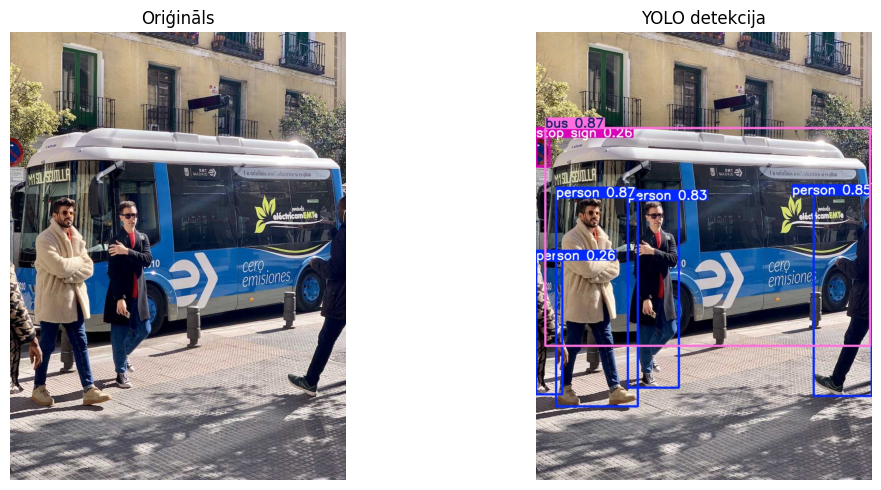

In [14]:
def analyze_image(image_path):
    print(f"\n{'='*50}")
    print(f"Analizējam: {image_path}")
    print(f"{'='*50}")

    # 1. Ielādējam attēlu
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 2. YOLO objektu detekcija
    results = yolo_model(image_path, verbose=False)
    detected = results[0].boxes
    print(f"\n[YOLO] Atrasti objekti:")
    if len(detected) == 0:
        print("  Neviens objekts netika atrasts")
    else:
        for box in detected:
            label = yolo_model.names[int(box.cls)]
            conf = float(box.conf) * 100
            print(f"  - {label} ({conf:.1f}%)")

    # 3. OCR teksta iegūšana
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)[1]
    text = pytesseract.image_to_string(Image.fromarray(thresh)).strip()
    print(f"\n[OCR] Iegūtais teksts:")
    if text:
        print(f"  {text[:200]}")
    else:
        print("  Teksts netika atrasts")

    # 4. Vizualizācija
    import matplotlib.image as mpimg
    results[0].save("result_yolo.jpg")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(image_rgb)
    ax1.set_title("Oriģināls")
    ax1.axis("off")
    result_img = mpimg.imread("result_yolo.jpg")
    ax2.imshow(result_img)
    ax2.set_title("YOLO detekcija")
    ax2.axis("off")
    plt.tight_layout()
    plt.show()

# Testējam
analyze_image("street.jpg")

In [13]:
from ultralytics import YOLO
import cv2
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

yolo_model = YOLO("yolov8n.pt")